# Probabilistic Day-Ahead Electricity Load Forecasting

**Spectral structure, transparent benchmarks and calibration on Belgian grid data.**

Electricity demand is strongly periodic, but periodicity is not the same as
predictability. This study asks how much of Belgian quarter-hourly load can be
forecast one day ahead from temporal structure alone, and whether the resulting
uncertainty estimates are statistically calibrated.

Before building anything, increment 1 audits what is already in the data: Elia
publishes an operational day-ahead forecast with P10/P90 bounds. That is a
professional reference — and a calibration question in its own right.

Companion study: [ElectricityResourceAdequacy](https://github.com/evrelegh/ElectricityResourceAdequacy)
— the same Fourier transform, used to convolve random variables rather than to
decompose temporal structure.

*Increment 1 — cells 01–05: acquisition, integrity, Elia audit, first figures.
No forecasting model yet.*


In [1]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 01 · §0 · Forecast contract & configuration                    v1.0.0
# provides ▸ np · pd · plt · requests · ELIA_BASE · ZONE · YEARS · START · END
#            TZ · H_ALIGN · FREQ · ORIGIN_CIVIL_HOUR · CACHE · RNG · DS_LOAD
# requires ▸ —
# ══════════════════════════════════════════════════════════════════════════
import warnings, os, pathlib
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

warnings.filterwarnings("ignore", message='Creating legend with loc="best"')

# --- zone & analysis window -------------------------------------------------
ZONE  = "BE"
YEARS = [2023]                       # multi-year capable; widen once v1 runs
START = pd.Timestamp(f"{min(YEARS)}-01-01")    # civil analysis window
END   = pd.Timestamp(f"{max(YEARS)}-12-31")
# Belgium is UTC+1/+2, so a UTC calendar year is not a civil year: pull with a
# month of margin either side and trim to complete civil days in CELL 03.
FETCH_START = (START - pd.offsets.MonthBegin(1)).strftime("%Y-%m-%d")
FETCH_END   = (END   + pd.offsets.MonthEnd(1)).strftime("%Y-%m-%d")

# --- the forecast contract --------------------------------------------------
# Fixed daily origin; target is the next civil day at quarter-hour resolution.
# Every feature for target T+h must be available at T. Enforced in CELL 07.
# Target is the FULL next Belgian civil day, so the number of horizons is a
# property of the calendar, not a constant: H_D = 92 / 96 / 100 at the DST
# transitions. H_ALIGN is only for horizon-resolved reporting, where the two
# odd days are excluded so every h carries the same sample size.
H_ALIGN = 96
FREQ    = "15min"
TZ   = "Europe/Brussels"             # civil time — calendar features only
                                     # UTC stays the computational time axis
# ASSUMPTION (to confirm against Elia metadata, not chosen post hoc):
# ods001 `dayaheadforecast` is published ahead of the day-ahead market gate.
# Treated here as issued at 12:00 civil time on D-1 for the whole of day D.
ORIGIN_CIVIL_HOUR = 12

# --- data endpoints ---------------------------------------------------------
ELIA_BASE = "https://opendata.elia.be/api/explore/v2.1"   # Opendatasoft, no token
DS_LOAD   = "ods001"                                      # measured + forecast load, BE

CACHE = pathlib.Path("cache"); CACHE.mkdir(exist_ok=True)
RNG   = np.random.default_rng(7)

print(f"zone={ZONE}  civil={START:%Y-%m-%d}..{END:%Y-%m-%d}  fetch={FETCH_START}..{FETCH_END}  H_align={H_ALIGN}  tz={TZ}")


zone=BE  civil=2023-01-01..2023-12-31  fetch=2022-12-01..2024-01-31  H_align=96  tz=Europe/Brussels


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 02 · §1 · Elia open-data client + cached pull                  v1.1.0
# provides ▸ elia_catalog · elia_peek · elia_fetch · _csv · LOAD
# requires ▸ requests · pd · ELIA_BASE · DS_LOAD · FETCH_START · FETCH_END · CACHE
# ══════════════════════════════════════════════════════════════════════════
# Client carried over unchanged from ElectricityResourceAdequacy CELL 02.
from time import sleep

def elia_catalog(query, limit=8):
    """List Elia datasets whose metadata matches `query` (id + title)."""
    r = requests.get(f"{ELIA_BASE}/catalog/datasets",
                     params={"where": f'"{query}"', "limit": limit}, timeout=30)
    r.raise_for_status()
    return pd.DataFrame([{"dataset_id": d["dataset_id"],
                          "title": d.get("metas", {}).get("default", {}).get("title", "")}
                         for d in r.json().get("results", [])])

def elia_peek(dataset_id, limit=5):
    """A few records to reveal the field names / schema (fast, no bulk)."""
    r = requests.get(f"{ELIA_BASE}/catalog/datasets/{dataset_id}/records",
                     params={"limit": limit}, timeout=30)
    r.raise_for_status()
    return pd.json_normalize(r.json().get("results", []))

def _csv(dataset_id, where="", order_by="", tries=4):
    """One streamed CSV-export request, retried on a dropped connection."""
    params = {k: v for k, v in dict(where=where, order_by=order_by).items() if v}
    url = f"{ELIA_BASE}/catalog/datasets/{dataset_id}/exports/csv"
    for a in range(1, tries + 1):
        try:
            with requests.get(url, params=params, timeout=300, stream=True) as r:
                r.raise_for_status()
                buf = StringIO()
                for chunk in r.iter_content(chunk_size=1 << 16, decode_unicode=True):
                    if chunk:
                        buf.write(chunk)
            buf.seek(0)
            return pd.read_csv(buf, sep=";")
        except (requests.exceptions.ChunkedEncodingError,
                requests.exceptions.ConnectionError,
                requests.exceptions.Timeout) as e:
            if a == tries:
                raise
            print(f"    {dataset_id}: {type(e).__name__} — retry {a}/{tries}")
            sleep(2 * a)

def elia_fetch(dataset_id, start, end):
    """Full series over [start, end], pulled MONTH BY MONTH and concatenated —
    small requests that survive where one giant export drops. Time field auto-detected."""
    cols = list(elia_peek(dataset_id, 1).columns)
    ts = next((c for c in cols if "datetime" in c.lower()
               or c.lower() in ("date", "timestamp")), None)
    if ts is None:
        raise ValueError(f"{dataset_id}: no time field in {cols}")
    edges = pd.date_range(pd.Timestamp(start).replace(day=1),
                          pd.Timestamp(end) + pd.offsets.MonthBegin(1), freq="MS")
    parts = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        w = f"{ts} >= '{lo:%Y-%m-%d}' AND {ts} < '{hi:%Y-%m-%d}'"
        d = _csv(dataset_id, where=w, order_by=ts)
        print(f"    {dataset_id} {lo:%Y-%m}: {len(d):6d} rows")
        parts.append(d)
    return pd.concat(parts, ignore_index=True)

# --- cached acquisition -----------------------------------------------------
def cached_fetch(dataset_id, start, end, refresh=False):
    """Pull once, reuse thereafter. Raw payload only — no transformation here."""
    f = CACHE / f"{dataset_id}_{start}_{end}.csv.gz"
    if f.exists() and not refresh:
        print(f"cache hit  {f.name}")
        return pd.read_csv(f)
    df = elia_fetch(dataset_id, start, end)
    df.to_csv(f, index=False, compression="gzip")
    print(f"cached     {f.name}  {df.shape}")
    return df

print(f"--- {DS_LOAD} columns ---")
print(list(elia_peek(DS_LOAD).columns))

LOAD = cached_fetch(DS_LOAD, FETCH_START, FETCH_END)
print(f"\nLOAD: {LOAD.shape}")
print(LOAD.head(3).to_string(index=False))


--- ods001 columns ---
['datetime', 'resolutioncode', 'totalload', 'mostrecentforecast', 'mostrecentconfidence10', 'mostrecentconfidence90', 'dayaheadforecast', 'dayaheadconfidence10', 'dayaheadconfidence90', 'weekaheadforecast']
    ods001 2022-12:   2976 rows
    ods001 2023-01:   2976 rows
    ods001 2023-02:   2688 rows
    ods001 2023-03:   2976 rows
    ods001 2023-04:   2880 rows
    ods001 2023-05:   2976 rows
    ods001 2023-06:   2880 rows
    ods001 2023-07:   2976 rows
    ods001 2023-08:   2976 rows
    ods001 2023-09:   2880 rows
    ods001 2023-10:   2976 rows
    ods001 2023-11:   2880 rows
    ods001 2023-12:   2976 rows
    ods001 2024-01:   2976 rows
cached     ods001_2022-12-01_2024-01-31.csv.gz  (40992, 10)

LOAD: (40992, 10)
                 datetime resolutioncode  totalload  mostrecentforecast  mostrecentconfidence10  mostrecentconfidence90  dayaheadforecast  dayaheadconfidence10  dayaheadconfidence90  weekaheadforecast
2022-12-01T00:00:00+00:00          PT15M  

In [3]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 03 · §1 · Data integrity — hard gate on the time axis          v1.0.0
# provides ▸ L · easter · be_holidays · expected_slots
# requires ▸ LOAD · pd · np · TZ · FREQ · START · END
# ══════════════════════════════════════════════════════════════════════════
# Nothing downstream is trusted unless this cell passes. Failures raise.

FIELDS = {"y": "totalload", "yhat_da": "dayaheadforecast",
          "q10_da": "dayaheadconfidence10", "q90_da": "dayaheadconfidence90"}

missing = [c for c in FIELDS.values() if c not in LOAD.columns]
assert not missing, f"ods001 missing expected fields: {missing}\ngot: {list(LOAD.columns)}"

L = (LOAD.assign(datetime=pd.to_datetime(LOAD["datetime"], utc=True))
         .rename(columns={v: k for k, v in FIELDS.items()})
         [["datetime", *FIELDS.keys()]]
         .sort_values("datetime").reset_index(drop=True))

# --- time-axis gate ---------------------------------------------------------
assert L["datetime"].is_unique, (
    f"duplicate timestamps: {int(L['datetime'].duplicated().sum())} — "
    "check ods001 for a resolutioncode/region split")
assert L["datetime"].is_monotonic_increasing, "timestamps not sorted"

# Uniform spacing on the UTC axis is the strong gate: it makes the series a
# contiguous grid, and tz_convert only relabels it. A missing quarter shows up
# here as a 30-min step, so no separate civil-grid test is needed downstream.
gaps = L["datetime"].diff().dropna()
bad_gap = gaps[gaps != pd.Timedelta(FREQ)]
assert bad_gap.empty, (
    f"irregular spacing on the UTC axis — {len(bad_gap)} step(s), "
    f"sizes {sorted(set(bad_gap))[:5]}, first at "
    f"{L.loc[bad_gap.index[0], 'datetime']}")

# --- civil-time calendar features ------------------------------------------
def easter(year):
    """Gregorian Easter Sunday — anonymous algorithm."""
    a, b, c = year % 19, year // 100, year % 100
    d, e = b // 4, b % 4
    f, g = (b + 8) // 25, (b - (b + 8) // 25 + 1) // 3
    h = (19 * a + b - d - g + 15) % 30
    i, k = c // 4, c % 4
    m = (32 + 2 * e + 2 * i - h - k) % 7
    n = (a + 11 * h + 22 * m) // 451
    mo = (h + m - 7 * n + 114) // 31
    return pd.Timestamp(year=year, month=mo, day=(h + m - 7 * n + 114) % 31 + 1)

def be_holidays(years):
    """Belgian public holidays as civil dates — fixed plus Easter-derived."""
    out = []
    for y in years:
        e = easter(y)
        out += [pd.Timestamp(f"{y}-01-01"), e + pd.Timedelta(days=1),
                pd.Timestamp(f"{y}-05-01"), e + pd.Timedelta(days=39),
                e + pd.Timedelta(days=50),  pd.Timestamp(f"{y}-07-21"),
                pd.Timestamp(f"{y}-08-15"), pd.Timestamp(f"{y}-11-01"),
                pd.Timestamp(f"{y}-11-11"), pd.Timestamp(f"{y}-12-25")]
    return pd.DatetimeIndex(sorted(out))

civ = L["datetime"].dt.tz_convert(TZ)
L["civil_date"] = civ.dt.normalize().dt.tz_localize(None)
L["qod"]        = civ.dt.hour * 4 + civ.dt.minute // 15      # 0..95, civil clock
L["hour"]       = civ.dt.hour
L["dow"]        = civ.dt.dayofweek
L["month"]      = civ.dt.month
L["is_weekend"] = L["dow"] >= 5

# --- trim to complete civil days inside the analysis window ----------------
# A civil day is 96 quarters except at the DST transitions (92 / 100). Length
# is derived from the zone itself, not asserted. Partial days at the fetch
# boundary are dropped: a 96-quarter lag across them would be silently wrong.
def expected_slots(d):
    a = pd.Timestamp(d, tz=TZ); b = pd.Timestamp(d + pd.Timedelta(days=1), tz=TZ)
    return int((b - a) / pd.Timedelta(FREQ))

L = L[L["civil_date"].between(START, END)].copy()
per_day = L.groupby("civil_date").size()
exp = per_day.index.to_series().map(expected_slots)
incomplete = per_day[per_day != exp]
if len(incomplete):
    print("dropped incomplete civil days:",
          dict(zip(incomplete.index.strftime("%Y-%m-%d"), incomplete.values)))
L = L[~L["civil_date"].isin(incomplete.index)].reset_index(drop=True)

per_day = L.groupby("civil_date").size()
exp = per_day.index.to_series().map(expected_slots)
assert (per_day == exp).all(), f"incomplete civil days remain:\n{per_day[per_day != exp]}"
assert L["qod"].between(0, 95).all(), "quarter-of-day outside 0..95"
dst = per_day[per_day != 96]
print(f"complete civil days: {len(per_day)}  slots: {len(L)}")
print("DST days:", dict(zip(dst.index.strftime("%Y-%m-%d"), dst.values)) or "none")

HOL = be_holidays(sorted({*L["civil_date"].dt.year}))
L["is_holiday"] = L["civil_date"].isin(HOL)

# --- published quantile ordering -------------------------------------------
band = L.dropna(subset=["q10_da", "q90_da"])
bad = int((band["q10_da"] > band["q90_da"]).sum())
assert bad == 0, f"{bad} slots with published P10 > P90"

# --- missingness, reported not silently dropped -----------------------------
print("\nmissing per field:")
print(L[list(FIELDS)].isna().sum().to_string())
print(f"\nL: {L.shape}  {L['datetime'].min()} .. {L['datetime'].max()}")
print(f"holidays in window: {len(HOL[(HOL >= L['civil_date'].min()) & (HOL <= L['civil_date'].max())])}")


complete civil days: 365  slots: 35040
DST days: {'2023-03-26': np.int64(92), '2023-10-29': np.int64(100)}

missing per field:
y          3
yhat_da    0
q10_da     0
q90_da     0

L: (35040, 12)  2022-12-31 23:00:00+00:00 .. 2023-12-31 22:45:00+00:00
holidays in window: 10


In [4]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 04 · §2 · Elia day-ahead audit — accuracy and calibration      v1.0.0
# provides ▸ pinball · coverage · width · score_point · score_prob · score
#            A · elia_overall · common
# requires ▸ L · pd · np
# ══════════════════════════════════════════════════════════════════════════
# No model of our own yet. What does the operational forecast already deliver?

def pinball(y, q, alpha):
    """Quantile (pinball) loss at level alpha — proper scoring rule."""
    y, q = np.asarray(y, float), np.asarray(q, float)
    d = y - q
    return float(np.mean(np.maximum(alpha * d, (alpha - 1) * d)))

def coverage(y, lo, hi):
    """Empirical frequency of the realised value falling inside [lo, hi]."""
    y, lo, hi = map(lambda a: np.asarray(a, float), (y, lo, hi))
    return float(np.mean((y >= lo) & (y <= hi)))

def width(lo, hi):
    """Mean interval width — sharpness. Coverage alone is trivially gameable."""
    return float(np.mean(np.asarray(hi, float) - np.asarray(lo, float)))

def score_point(d, y="y", yhat="yhat_da"):
    """Point accuracy on the sample where actual and point forecast both exist."""
    d = d.dropna(subset=[y, yhat])
    if not len(d):
        return pd.Series({"n_point": 0}, dtype=float)
    e = d[y] - d[yhat]
    return pd.Series({"n_point": len(d), "bias": e.mean(), "MAE": e.abs().mean(),
                      "RMSE": np.sqrt((e ** 2).mean())})

def score_prob(d, y="y", lo="q10_da", hi="q90_da"):
    """Calibration and sharpness on the sample where both bounds exist.
    pin_mean is a compact interval indicator, NOT a CRPS: two quantiles do not
    determine the predictive distribution."""
    d = d.dropna(subset=[y, lo, hi])
    if not len(d):
        return pd.Series({"n_prob": 0}, dtype=float)
    p10, p90 = pinball(d[y], d[lo], 0.10), pinball(d[y], d[hi], 0.90)
    return pd.Series({"n_prob": len(d), "cov80": coverage(d[y], d[lo], d[hi]),
                      "width": width(d[lo], d[hi]), "pin10": p10, "pin90": p90,
                      "pin_mean": 0.5 * (p10 + p90)})

def score(d):
    """Point and probabilistic metrics kept on their own samples — a missing
    confidence bound must not silently shrink the population behind MAE."""
    return pd.concat([score_point(d), score_prob(d)])

# ASSUMPTION (to confirm against Elia metadata, as with the forecast origin):
# `dayaheadconfidence10/90` are treated here as the 10th and 90th percentiles
# of Elia's predictive distribution, hence a nominal 80% central interval.
A = L.dropna(subset=["y", "yhat_da"]).copy()
A["e"] = A["y"] - A["yhat_da"]
A["inside"] = (A["y"] >= A["q10_da"]) & (A["y"] <= A["q90_da"])

# Ex-post diagnostic stratifier: realised load is not available at forecast
# time, so this is for reading the error, never a feature. The forecast-load
# decile is the ex-ante operational counterpart.
A["realised_load_decile"] = pd.qcut(A["y"], 10, labels=False, duplicates="drop")
A["forecast_load_decile"] = pd.qcut(A["yhat_da"], 10, labels=False, duplicates="drop")
A["daytype"] = np.where(A["is_holiday"], "holiday",
                np.where(A["is_weekend"], "weekend", "working day"))

elia_overall = score(A)
print("Elia day-ahead — overall")
print(elia_overall.round(3).to_string())
print(f"\nnominal P10-P90 coverage = 0.80  ·  realised = {elia_overall['cov80']:.3f}")

# Same metrics restricted to the common sample, so any population difference
# between the point and probabilistic figures above is visible, not implicit.
common = A.dropna(subset=["y", "yhat_da", "q10_da", "q90_da"])
if len(common) != int(elia_overall["n_point"]):
    print(f"\npoint sample {int(elia_overall['n_point'])} vs common sample {len(common)}"
          f" — point metrics on the common sample:")
    print(score_point(common).round(3).to_string())
else:
    print("\npoint and probabilistic samples coincide")

def by(key, label=None):
    t = A.groupby(key).apply(score).round(3)
    print(f"\n--- by {label or key} ---")
    print(t.to_string())
    return t

by_hour    = by("hour", "hour of civil day")
by_month   = by("month")
by_daytype = by("daytype", "day type")
by_rdecile = by("realised_load_decile", "realised-load decile (ex post)")
by_fdecile = by("forecast_load_decile", "forecast-load decile (ex ante)")

# Conditional coverage is where an overall 80% can hide an operational problem.
print("\n--- P10-P90 coverage, worst 8 hour x season cells ---")
A["season"] = A["month"].map({12: "DJF", 1: "DJF", 2: "DJF", 3: "MAM", 4: "MAM", 5: "MAM",
                              6: "JJA", 7: "JJA", 8: "JJA", 9: "SON", 10: "SON", 11: "SON"})
cc = (A.groupby(["season", "hour"])
        .agg(cov=("inside", "mean"), n=("inside", "size")).reset_index())
print(cc.nsmallest(8, "cov").round(3).to_string(index=False))


Elia day-ahead — overall
n_point     35037.000
bias          -59.860
MAE           259.865
RMSE          341.957
n_prob      35037.000
cov80           0.721
width         745.847
pin10          65.530
pin90          61.885
pin_mean       63.708

nominal P10-P90 coverage = 0.80  ·  realised = 0.721

point and probabilistic samples coincide

--- by hour of civil day ---
      n_point     bias      MAE     RMSE  n_prob  cov80    width   pin10   pin90  pin_mean
hour                                                                                      
0      1460.0 -104.182  230.530  298.317  1460.0  0.801  753.914  54.804  54.052    54.428
1      1460.0  -83.513  222.706  297.914  1460.0  0.771  723.958  58.044  53.034    55.539
2      1460.0  -77.266  217.158  302.651  1460.0  0.751  685.801  61.899  52.944    57.422
3      1460.0  -72.716  216.179  301.979  1460.0  0.753  684.099  61.083  52.713    56.898
4      1460.0  -76.371  217.381  305.217  1460.0  0.758  684.110  61.254  53.850   

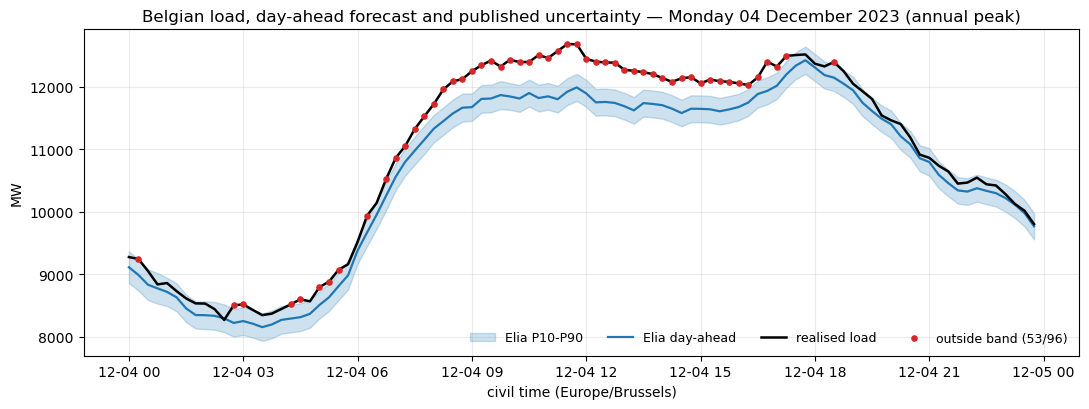

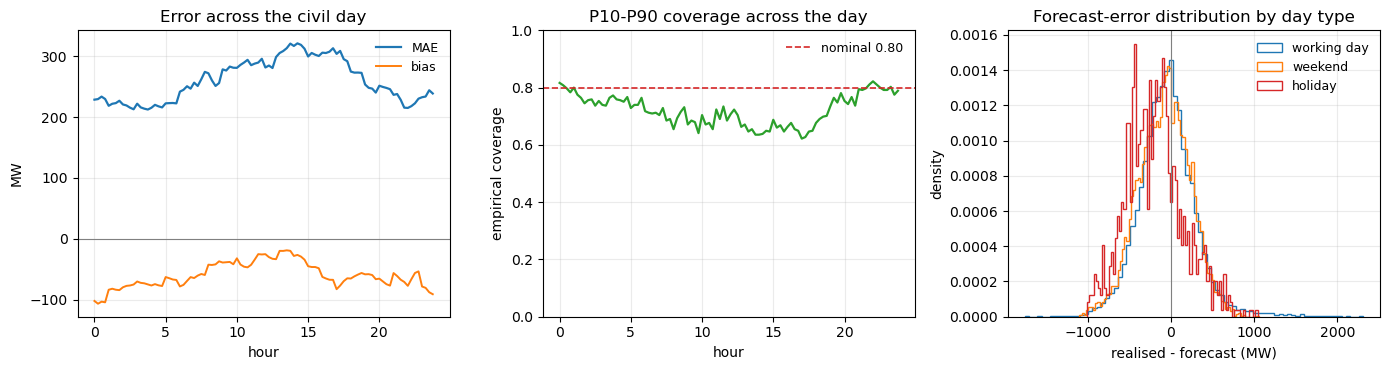

annual peak day: 2023-12-04  peak = 12,681 MW
widest band day: 2023-12-29


In [5]:
# ══════════════════════════════════════════════════════════════════════════
# CELL 05 · §3 · First figures — is the data interesting?             v1.0.0
# provides ▸ —   ·   requires ▸ A · by_hour · plt · np · pd · TZ
# ══════════════════════════════════════════════════════════════════════════
# One day in full, then the shape of the error and the band across the day.

peak_day = A.loc[A["y"].idxmax(), "civil_date"]
d = A[A["civil_date"] == peak_day].copy()
d["t"] = d["datetime"].dt.tz_convert(TZ)

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.fill_between(d["t"], d["q10_da"], d["q90_da"], alpha=.22, color="tab:blue",
                label="Elia P10-P90")
ax.plot(d["t"], d["yhat_da"], color="tab:blue", lw=1.6, label="Elia day-ahead")
ax.plot(d["t"], d["y"], color="black", lw=1.8, label="realised load")
out = d[~d["inside"]]
ax.scatter(out["t"], out["y"], s=14, color="tab:red", zorder=5,
           label=f"outside band ({len(out)}/{len(d)})")
ax.set(title=f"Belgian load, day-ahead forecast and published uncertainty — "
             f"{peak_day:%A %d %B %Y} (annual peak)",
       xlabel=f"civil time ({TZ})", ylabel="MW")
ax.legend(frameon=False, ncol=4, fontsize=9); ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

q = A.groupby("qod").agg(mae=("e", lambda s: s.abs().mean()),
                         bias=("e", "mean"))
axes[0].plot(q.index / 4, q["mae"], color="tab:blue", lw=1.6, label="MAE")
axes[0].plot(q.index / 4, q["bias"], color="tab:orange", lw=1.4, label="bias")
axes[0].axhline(0, color="grey", lw=.8)
axes[0].set(title="Error across the civil day", xlabel="hour", ylabel="MW")
axes[0].legend(frameon=False, fontsize=9); axes[0].grid(alpha=.25)

c = A.groupby("qod")["inside"].mean()
axes[1].plot(c.index / 4, c, color="tab:green", lw=1.6)
axes[1].axhline(.80, color="tab:red", ls="--", lw=1.2, label="nominal 0.80")
axes[1].set(title="P10-P90 coverage across the day", xlabel="hour",
            ylabel="empirical coverage", ylim=(0, 1))
axes[1].legend(frameon=False, fontsize=9); axes[1].grid(alpha=.25)

for dt, col in [("working day", "tab:blue"), ("weekend", "tab:orange"),
                ("holiday", "tab:red")]:
    s = A[A["daytype"] == dt]
    if len(s):
        axes[2].hist(s["e"], bins=80, histtype="step", density=True,
                     color=col, lw=1.4, label=dt)
axes[2].axvline(0, color="grey", lw=.8)
axes[2].set(title="Forecast-error distribution by day type", xlabel="realised - forecast (MW)",
            ylabel="density")
axes[2].legend(frameon=False, fontsize=9); axes[2].grid(alpha=.25)

plt.tight_layout(); plt.show()

print(f"annual peak day: {peak_day:%Y-%m-%d}  peak = {A['y'].max():,.0f} MW")
print(f"widest band day: {A.groupby('civil_date').apply(lambda g: (g.q90_da - g.q10_da).mean()).idxmax():%Y-%m-%d}")
